# 03 — Modelling

Trains all models on both binary and multi-class tasks, evaluates performance, and plots confusion matrices and ROC curves.

In [1]:
import sys
sys.path.append('../')

import joblib
import pandas as pd
import matplotlib.pyplot as plt

from src.train import train_all
from src.evaluate import evaluate_all, plot_confusion_matrix, plot_roc_curves, plot_feature_importance

%matplotlib inline

## Load Preprocessed Data

In [2]:
data = joblib.load('../models/preprocessed_data.pkl')

X_train       = data['X_train']
X_test        = data['X_test']
y_train_bin   = data['y_train_bin']
y_test_bin    = data['y_test_bin']
y_train_multi = data['y_train_multi']
y_test_multi  = data['y_test_multi']
feature_cols  = data['feature_cols']

## Binary Classification

In [3]:
binary_models, _ = train_all(X_train, y_train_bin, label_type='binary', save=True)

Training logistic_regression (binary)...


/Users/hermann/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/hermann/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/hermann/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/hermann/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/Users/hermann/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: overflow encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise 

  Saved to /Users/hermann/Desktop/SkoleProjekt/IDS_System/notebooks/../src/../models/logistic_regression_binary.pkl
Training decision_tree (binary)...


  Saved to /Users/hermann/Desktop/SkoleProjekt/IDS_System/notebooks/../src/../models/decision_tree_binary.pkl
Training random_forest (binary)...


  Saved to /Users/hermann/Desktop/SkoleProjekt/IDS_System/notebooks/../src/../models/random_forest_binary.pkl
Training xgboost (binary)...


  Saved to /Users/hermann/Desktop/SkoleProjekt/IDS_System/notebooks/../src/../models/xgboost_binary.pkl
Training mlp (binary)...


/Users/hermann/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/hermann/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/hermann/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


  Saved to /Users/hermann/Desktop/SkoleProjekt/IDS_System/notebooks/../src/../models/mlp_binary.pkl


In [4]:
results_bin = evaluate_all(binary_models, X_test, y_test_bin, label_type='binary')
results_bin


logistic_regression:
              precision    recall  f1-score   support

           0       0.65      0.93      0.77      9711
           1       0.93      0.62      0.74     12833

    accuracy                           0.75     22544
   macro avg       0.79      0.78      0.75     22544
weighted avg       0.81      0.75      0.75     22544


decision_tree:
              precision    recall  f1-score   support

           0       0.68      0.97      0.80      9711
           1       0.96      0.65      0.78     12833

    accuracy                           0.79     22544
   macro avg       0.82      0.81      0.79     22544
weighted avg       0.84      0.79      0.79     22544


random_forest:
              precision    recall  f1-score   support

           0       0.66      0.97      0.78      9711
           1       0.97      0.62      0.75     12833

    accuracy                           0.77     22544
   macro avg       0.81      0.79      0.77     22544
weighted avg       0

/Users/hermann/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/hermann/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/hermann/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/hermann/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/hermann/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/hermann/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


,accuracy,precision,recall,f1
model,,,,
logistic_regression,0.753903,0.925178,0.617626,0.740748
decision_tree,0.787660,0.964872,0.650666,0.777214
random_forest,0.769917,0.966106,0.617471,0.753411
xgboost,0.800878,0.967818,0.672563,0.793619
mlp,0.795289,0.971865,0.659472,0.785757


/Users/hermann/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/hermann/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/hermann/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/hermann/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/hermann/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/hermann/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


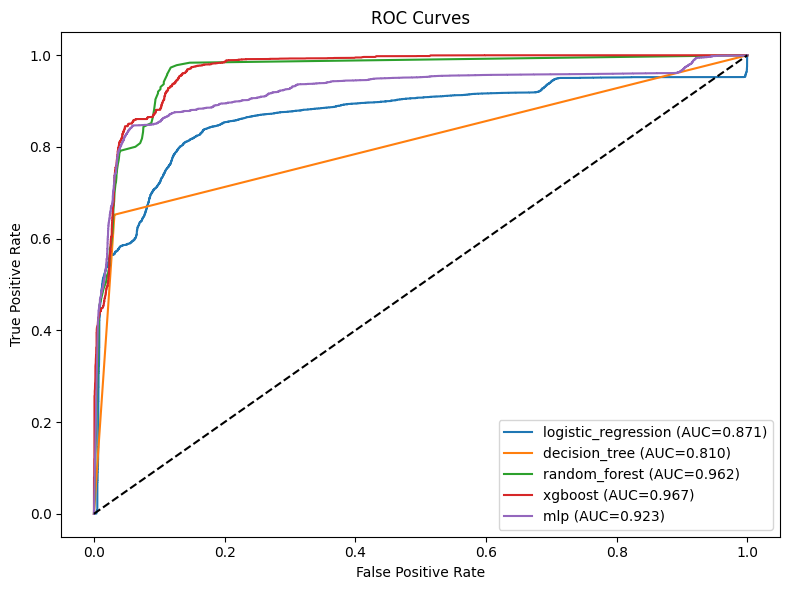

In [5]:
# ROC curves (binary)
fig = plot_roc_curves(binary_models, X_test, y_test_bin)
plt.show()

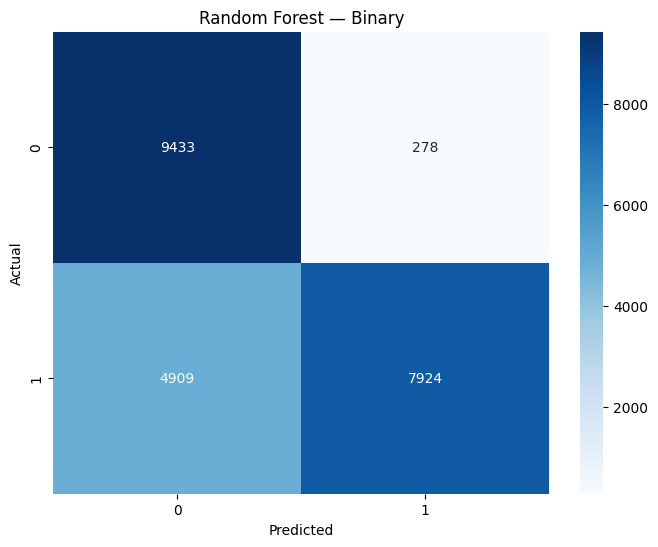

In [6]:
# Confusion matrix for best model (Random Forest)
rf = binary_models['random_forest']
y_pred_rf = rf.predict(X_test)
ax = plot_confusion_matrix(y_test_bin, y_pred_rf, labels=[0, 1], title='Random Forest — Binary')
plt.show()

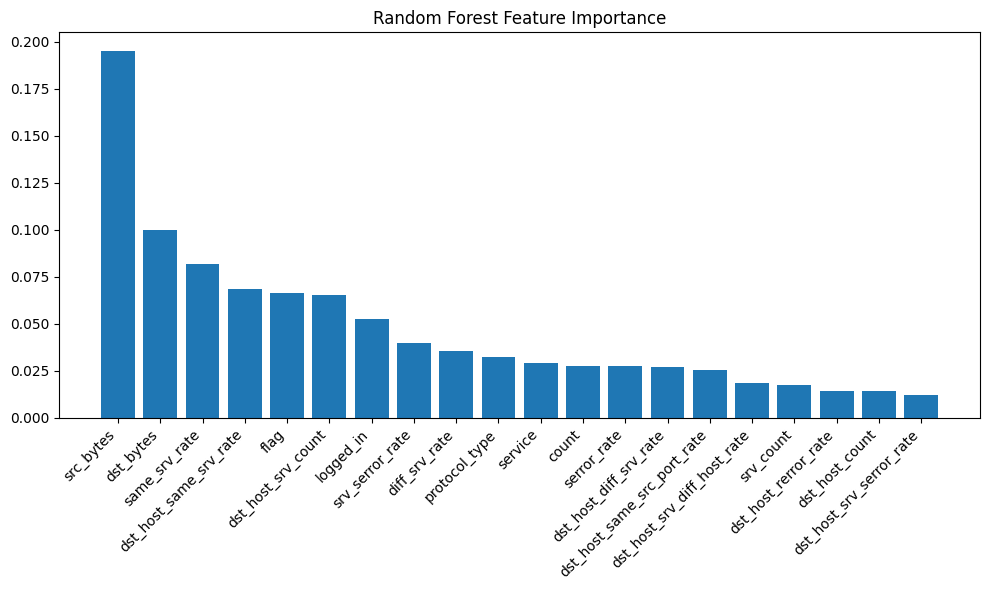

In [7]:
# Feature importance (Random Forest)
fig = plot_feature_importance(rf, feature_cols, top_n=20, title='Random Forest Feature Importance')
plt.show()

## Multi-class Classification

In [8]:
multi_models, le = train_all(X_train, y_train_multi, label_type='multi', save=True)

Training logistic_regression (multi)...


/Users/hermann/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/hermann/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/hermann/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/hermann/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:336: RuntimeWarning: divide by zero encountered in matmul
  grad[:, :n_features] = grad_pointwise.T @ X + l2_reg_strength * weights
/Users/hermann/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linea

  Saved to /Users/hermann/Desktop/SkoleProjekt/IDS_System/notebooks/../src/../models/logistic_regression_multi.pkl
Training decision_tree (multi)...


  Saved to /Users/hermann/Desktop/SkoleProjekt/IDS_System/notebooks/../src/../models/decision_tree_multi.pkl
Training random_forest (multi)...


  Saved to /Users/hermann/Desktop/SkoleProjekt/IDS_System/notebooks/../src/../models/random_forest_multi.pkl
Training xgboost (multi)...


  Saved to /Users/hermann/Desktop/SkoleProjekt/IDS_System/notebooks/../src/../models/xgboost_multi.pkl
Training mlp (multi)...


/Users/hermann/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/hermann/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/hermann/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


  Saved to /Users/hermann/Desktop/SkoleProjekt/IDS_System/notebooks/../src/../models/mlp_multi.pkl


In [9]:
results_multi = evaluate_all(multi_models, X_test, y_test_multi, label_type='multi', le=le)
results_multi


logistic_regression:
              precision    recall  f1-score   support

         DoS       0.97      0.79      0.87      7458
       Probe       0.84      0.75      0.79      2421
         R2L       0.44      0.00      0.01      2754
         U2R       0.87      0.07      0.12       200
      normal       0.66      0.98      0.79      9711

    accuracy                           0.76     22544
   macro avg       0.76      0.52      0.52     22544
weighted avg       0.76      0.76      0.71     22544



/Users/hermann/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/hermann/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/hermann/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b



decision_tree:


              precision    recall  f1-score   support

         DoS       0.95      0.81      0.87      7458
       Probe       0.69      0.64      0.66      2421
         R2L       0.97      0.12      0.22      2754
         U2R       0.52      0.07      0.13       200
      normal       0.69      0.97      0.81      9711

    accuracy                           0.77     22544
   macro avg       0.76      0.52      0.54     22544
weighted avg       0.81      0.77      0.74     22544


random_forest:


              precision    recall  f1-score   support

         DoS       0.96      0.77      0.85      7458
       Probe       0.88      0.68      0.76      2421
         R2L       0.98      0.04      0.07      2754
         U2R       0.40      0.01      0.02       200
      normal       0.65      0.97      0.78      9711

    accuracy                           0.75     22544
   macro avg       0.77      0.49      0.50     22544
weighted avg       0.81      0.75      0.71     22544


xgboost:


              precision    recall  f1-score   support

         DoS       0.96      0.83      0.89      7458
       Probe       0.85      0.66      0.74      2421
         R2L       0.98      0.07      0.13      2754
         U2R       0.55      0.03      0.06       200
      normal       0.67      0.97      0.79      9711

    accuracy                           0.77     22544
   macro avg       0.80      0.51      0.52     22544
weighted avg       0.82      0.77      0.73     22544


mlp:
              precision    recall  f1-score   support

         DoS       0.95      0.80      0.87      7458
       Probe       0.75      0.62      0.68      2421
         R2L       0.88      0.03      0.06      2754
         U2R       0.83      0.10      0.18       200
      normal       0.67      0.97      0.79      9711

    accuracy                           0.75     22544
   macro avg       0.82      0.50      0.51     22544
weighted avg       0.80      0.75      0.71     22544



/Users/hermann/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/hermann/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/hermann/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


,accuracy,precision,recall,f1
model,,,,
logistic_regression,0.762243,0.759347,0.762243,0.714606
decision_tree,0.769029,0.809857,0.769029,0.736273
random_forest,0.750843,0.814120,0.750843,0.708538
xgboost,0.771691,0.822723,0.771691,0.732783
mlp,0.754391,0.797923,0.754391,0.709665


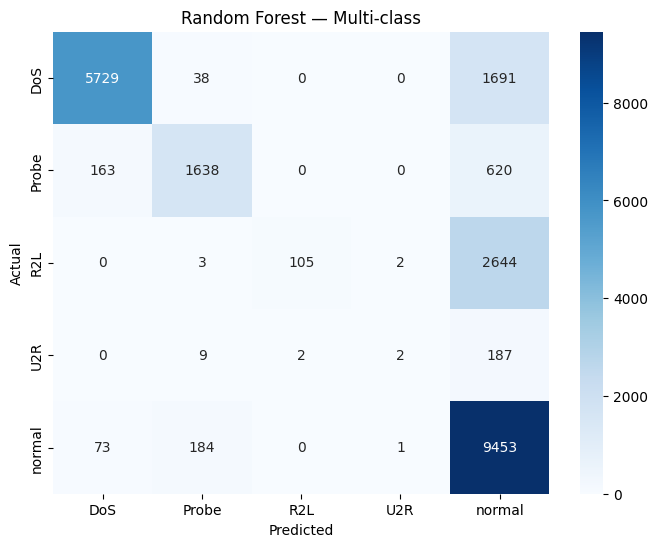

In [10]:
# Confusion matrix for Random Forest (multi-class)
rf_multi = multi_models['random_forest']
y_pred_multi = le.inverse_transform(rf_multi.predict(X_test))
categories = le.classes_.tolist()

ax = plot_confusion_matrix(y_test_multi, y_pred_multi, labels=categories,
                           title='Random Forest — Multi-class')
plt.show()

## Summary

In [11]:
print('=== Binary Classification ===')
print(results_bin.round(4).to_string())
print()
print('=== Multi-class Classification (weighted avg) ===')
print(results_multi.round(4).to_string())

=== Binary Classification ===
                     accuracy  precision  recall      f1
model                                                   
logistic_regression    0.7539     0.9252  0.6176  0.7407
decision_tree          0.7877     0.9649  0.6507  0.7772
random_forest          0.7699     0.9661  0.6175  0.7534
xgboost                0.8009     0.9678  0.6726  0.7936
mlp                    0.7953     0.9719  0.6595  0.7858

=== Multi-class Classification (weighted avg) ===
                     accuracy  precision  recall      f1
model                                                   
logistic_regression    0.7622     0.7593  0.7622  0.7146
decision_tree          0.7690     0.8099  0.7690  0.7363
random_forest          0.7508     0.8141  0.7508  0.7085
xgboost                0.7717     0.8227  0.7717  0.7328
mlp                    0.7544     0.7979  0.7544  0.7097
